In [2]:
import numpy as np
import torch
torch.set_printoptions(edgeitems=2, threshold=50)

In [3]:
import imageio

dir_path = "../data/p1ch4/volumetric-dicom/2-LUNG 3.0  B70f-04083"
vol_arr = imageio.volread(dir_path, 'DICOM')
vol_arr.shape

Reading DICOM (examining files): 1/99 files (1.0%99/99 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 35/99  (35.472/99  (72.799/99  (100.0%)


(99, 512, 512)

In [4]:
vol = torch.from_numpy(vol_arr).float()
print(vol.shape)
vol = torch.unsqueeze(vol, 0)

vol.shape

torch.Size([99, 512, 512])


torch.Size([1, 99, 512, 512])

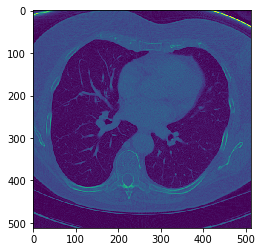

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(vol_arr[50])

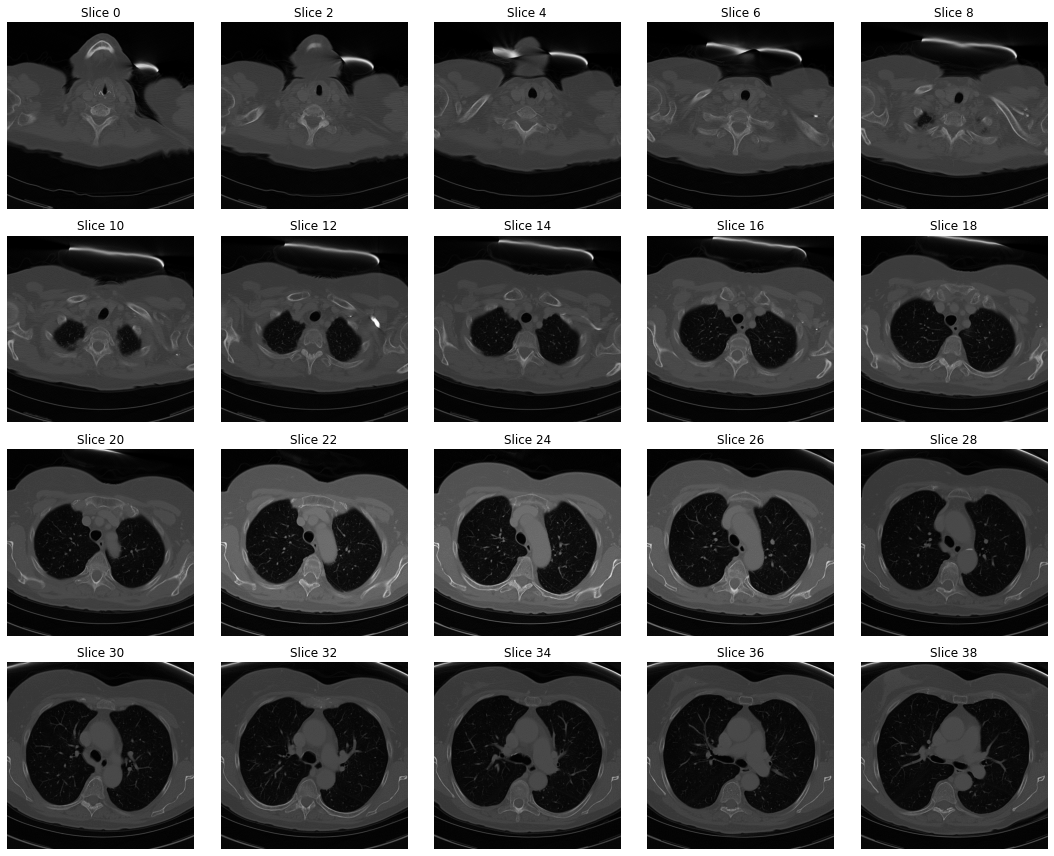

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#20 срезов с шагом 2
step = 2
num_slices = 20
start = 0
indices = np.arange(start, start + num_slices * step, step)  # [0,2,4,...,38]


rows = 4
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))


for ax, idx in zip(axes.flat, indices):
    ax.imshow(vol_arr[idx], cmap='gray')  
    ax.axis('off')
    ax.set_title(f'Slice {idx}')


plt.tight_layout()
plt.show()

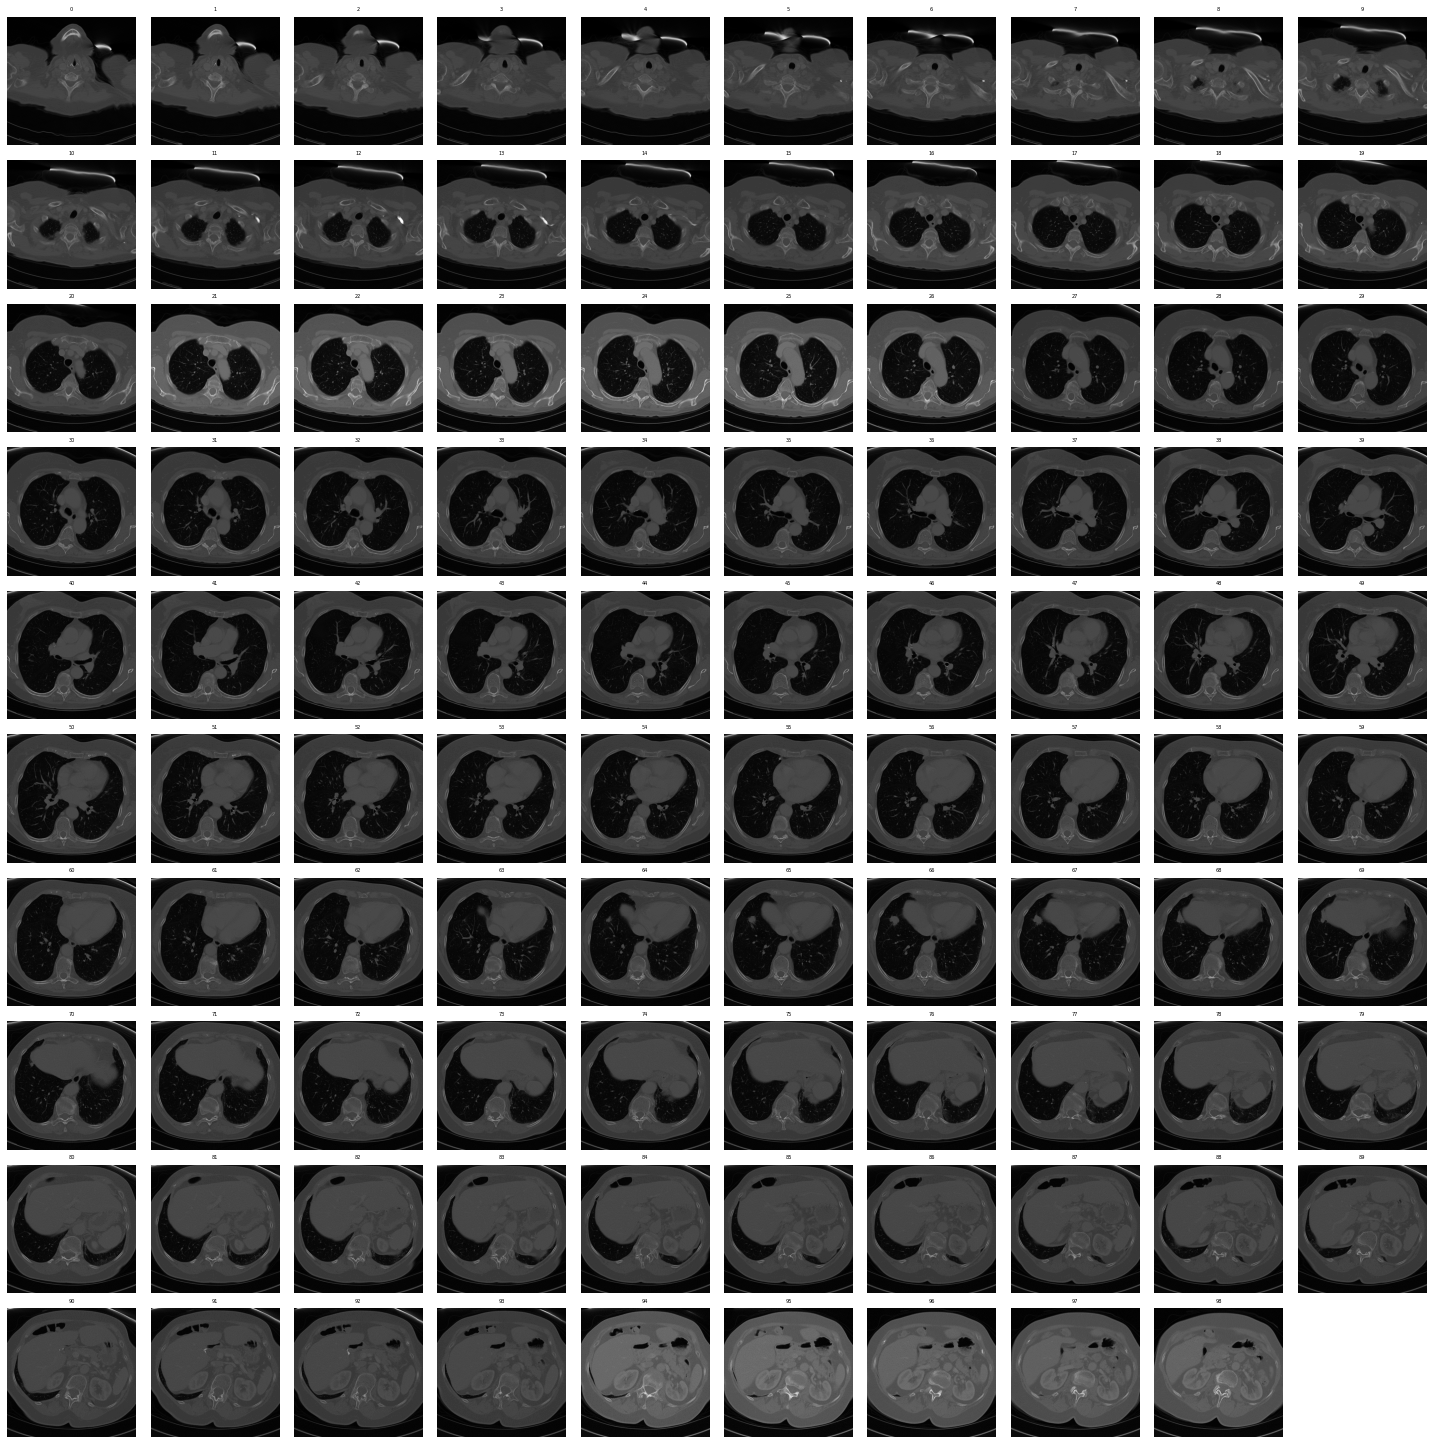

In [8]:

N = vol_arr.shape[0]  # 99


# cols = int(np.ceil(np.sqrt(N)))   # 10
# rows = int(np.ceil(N / cols))     # 10
cols = 10
rows = 10


fig, axes = plt.subplots(rows, cols, figsize=(20, 20))


for i, ax in enumerate(axes.flat):
    if i < N:
        ax.imshow(vol_arr[i], cmap='gray')
        ax.set_title(f'{i}', fontsize=5)
    ax.axis('off')  

plt.tight_layout(pad=0.5)
plt.show()